# 03 — Gold Layer: Analytical Aggregations

This notebook demonstrates the **Gold layer** — the consumption-ready analytical tables.

**Tables produced:**
| Table | Grain | Description |
|---|---|---|
| `daily_metrics` | ticker × trade_date | OHLCV + rolling volatility, avg volume, cumulative return |
| `portfolio_summary` | ticker | Period totals: total return, avg volume, avg volatility |
| `monthly_returns` | ticker × year × month | Monthly OHLC and return |

In [1]:
# Configuração do notebook da camada Gold (analytics).
import sys

sys.path.insert(0, "..")

import plotly.express as px
import polars as pl

pl.Config.set_tbl_rows(20)

polars.config.Config

## 1. Build Gold tables

In [ ]:
# 1) Constrói as 3 tabelas analíticas a partir da Silver:
#    - daily_metrics       (ticker × trade_date, com features de rolling window)
#    - portfolio_summary   (1 linha por ticker)
#    - monthly_returns     (ticker × ano × mês)
from lab_vacation260625.b3_data_plataform_ezequiel_fc.f_pipelines.c_gold_pipeline import (
    GoldPipeline,
)

tables = GoldPipeline().run()

for name, df in tables.items():
    print(f"{name:25s}: {len(df):>6,} rows  |  cols: {df.columns}")

{"timestamp": "2026-06-26T01:38:01.588931+00:00", "level": "INFO", "logger": "f_pipelines.gold_pipeline", "message": "GoldPipeline started", "module": "gold_pipeline", "func": "run", "line": 60, "name": "f_pipelines.gold_pipeline", "msg": "GoldPipeline started", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "\\\\wsl.localhost\\ubuntu-llm\\home\\efcardoso\\projects\\b3-data-plataform\\i_notebooks\\..\\f_pipelines\\gold_pipeline.py", "filename": "gold_pipeline.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 60, "funcName": "run", "created": 1782437881.5888958, "msecs": 588.0, "relativeCreated": 77889.0394, "thread": 29156, "threadName": "MainThread", "processName": "MainProcess", "process": 18428, "taskName": "Task-65"}
{"timestamp": "2026-06-26T01:38:01.590596+00:00", "level": "INFO", "logger": "f_pipelines.gold_pipeline", "message": "Reading Silver data for Gold pipeline", "module": "gold_pipeline", "func": "extract", "line": 41, "name": "f_pipeline

## 2. Daily metrics overview

In [3]:
# 2a) Amostra da tabela `daily_metrics`.
# Aqui aparecem as features derivadas: avg_volume_20d, volatility_20d, cum_return.
daily = tables.get("daily_metrics")
if daily is not None:
    daily.head(10)

In [4]:
# 2b) Comparativo de retorno acumulado entre os 5 ativos demo.
# Indicador clássico para "quanto você teria ganho/perdido se tivesse
# investido R$1 no início do período".
if daily is not None:
    top5 = ["PETR4.SA", "VALE3.SA", "ITUB4.SA", "BBDC4.SA", "ABEV3.SA"]
    plot_df = daily.filter(pl.col("ticker").is_in(top5)).sort("trade_date").to_pandas()

    fig = px.line(
        plot_df,
        x="trade_date",
        y="cum_return",
        color="ticker",
        title="Retorno Acumulado por Ativo — Camada Gold",
        labels={
            "trade_date": "Data da Negociação",
            "cum_return": "Retorno Acumulado",
            "ticker": "Ativo",
        },
    )
    fig.add_hline(y=0, line_dash="dash", line_color="grey")
    fig.update_layout(
        height=520,
        hovermode="x unified",
        template="plotly_white",
        legend=dict(title="Ativo", orientation="v", x=1.02, y=1),
        margin=dict(l=60, r=40, t=70, b=50),
    )
    fig.update_yaxes(tickformat=".1%")
    fig.update_xaxes(tickformat="%d/%m/%Y")
    fig.show()

In [5]:
# 2c) Volatilidade anualizada com janela móvel de 20 pregões.
# Fórmula: std(daily_return, 20) × sqrt(252) — onde 252 é o nº médio de pregões/ano.
if daily is not None:
    fig2 = px.line(
        plot_df,
        x="trade_date",
        y="volatility_20d",
        color="ticker",
        title="Volatilidade Anualizada — Janela Móvel de 20 dias",
        labels={
            "trade_date": "Data da Negociação",
            "volatility_20d": "Volatilidade Anualizada",
            "ticker": "Ativo",
        },
    )
    fig2.update_layout(
        height=520,
        hovermode="x unified",
        template="plotly_white",
        legend=dict(title="Ativo", orientation="v", x=1.02, y=1),
        margin=dict(l=60, r=40, t=70, b=50),
    )
    fig2.update_yaxes(tickformat=".1%")
    fig2.update_xaxes(tickformat="%d/%m/%Y")
    fig2.show()

## 3. Portfolio summary

In [6]:
# 3a) Ranking dos ativos pelo retorno total no período.
summary = tables.get("portfolio_summary")
if summary is not None:
    print("Top performers:")
    display(summary.head(10).to_pandas())

Top performers:


,ticker,first_date,last_date,total_return,avg_daily_volume,avg_volatility,period_high,period_low
0,ABEV3.SA,2026-03-27,2026-06-24,0.109756,2.775181e+07,0.339078,16.950001,14.330000
1,BPAC11.SA,2026-03-27,2026-06-24,0.002429,1.023034e+07,0.338793,64.339996,49.200001
2,ITUB4.SA,2026-03-27,2026-06-24,-0.011580,2.964894e+07,0.256586,47.040001,38.520000
3,VALE3.SA,2026-03-27,2026-06-24,-0.016076,1.887998e+07,0.291707,89.750000,77.699997
4,WEGE3.SA,2026-03-27,2026-06-24,-0.016874,8.147952e+06,0.329786,52.880001,41.779999
5,LREN3.SA,2026-03-27,2026-06-24,-0.026192,1.663205e+07,0.477037,15.910000,13.140000
6,BBDC4.SA,2026-03-27,2026-06-24,-0.046976,3.075411e+07,0.274813,21.260000,17.200001
7,RENT3.SA,2026-03-27,2026-06-24,-0.075083,9.488833e+06,0.436404,51.980000,39.119999
8,BBAS3.SA,2026-03-27,2026-06-24,-0.129303,2.368228e+07,0.281583,25.379999,19.000000
9,PETR4.SA,2026-03-27,2026-06-24,-0.225056,4.963668e+07,0.313987,49.779999,38.290001


In [7]:
# 3b) Dispersão Risco × Retorno.
# Cada ponto é um ativo; eixo X = volatilidade média, eixo Y = retorno total.
# Quadrante superior-esquerdo = melhor relação (alto retorno, baixo risco).
if summary is not None:
    sum_pd = summary.to_pandas()
    fig3 = px.scatter(
        sum_pd.dropna(subset=["total_return", "avg_volatility"]),
        x="avg_volatility",
        y="total_return",
        text="ticker",
        title="Risco x Retorno no Período (por Ativo)",
        labels={
            "avg_volatility": "Volatilidade Média (anualizada)",
            "total_return": "Retorno Total no Período",
            "ticker": "Ativo",
        },
        color="ticker",
    )
    fig3.update_traces(textposition="top center", marker=dict(size=12, line=dict(width=1, color="DarkSlateGrey")))
    fig3.update_layout(
        height=560,
        template="plotly_white",
        showlegend=False,
        margin=dict(l=60, r=40, t=70, b=60),
    )
    fig3.add_hline(y=0, line_dash="dash", line_color="grey")
    fig3.update_xaxes(tickformat=".1%")
    fig3.update_yaxes(tickformat=".1%")
    fig3.show()

## 4. Monthly returns heatmap

In [8]:
# 4a) Amostra da tabela `monthly_returns` (agregação mensal).
monthly = tables.get("monthly_returns")
if monthly is not None:
    monthly.head(10)

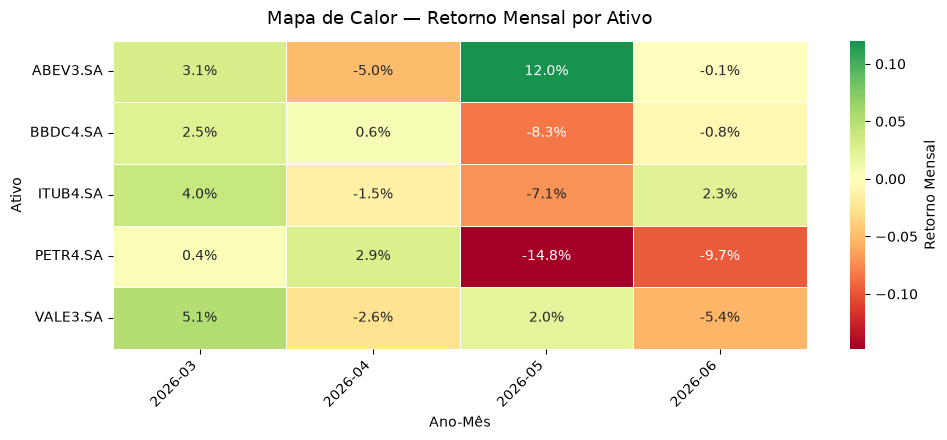

In [9]:
# 4b) Mapa de calor: retorno mensal por ativo.
# Eixo X = ano-mês, eixo Y = ativo; cor verde = ganho, vermelho = perda.
# Excelente para identificar visualmente meses bons/ruins de cada ativo.
import matplotlib.pyplot as plt
import seaborn as sns

if monthly is not None:
    # Pivota o long-format para wide (ticker x year-month) para o heatmap.
    pivot = (
        monthly
        .filter(pl.col("ticker").is_in(top5))
        .with_columns(
            pl.concat_str(
                [pl.col("year").cast(pl.Utf8), pl.lit("-"), pl.col("month").cast(pl.Utf8).str.zfill(2)]
            ).alias("ym")
        )
        .pivot(values="month_return", index="ticker", on="ym")
        .to_pandas()
        .set_index("ticker")
        .astype(float)
    )

    fig4, ax = plt.subplots(figsize=(max(10, 1.1 * pivot.shape[1]), 4.5))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".1%",
        cmap="RdYlGn",       # divergente: vermelho (perda) → verde (ganho)
        center=0,            # zero como ponto neutro do colormap
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Retorno Mensal"},
        ax=ax,
    )
    ax.set_title("Mapa de Calor — Retorno Mensal por Ativo", fontsize=13, pad=12)
    ax.set_xlabel("Ano-Mês")
    ax.set_ylabel("Ativo")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 5. Read persisted Gold tables

In [ ]:
# 5) Leitura das tabelas Gold persistidas em disco.
# Útil para confirmar a integridade do ciclo write→read em produção.
from d_processing.c_gold.aggregate import read_gold

gold_daily = read_gold("daily_metrics")
print(f"Persisted daily_metrics rows: {len(gold_daily):,}")

{"timestamp": "2026-06-26T01:43:33.634254+00:00", "level": "INFO", "logger": "d_processing.gold.aggregate", "message": "Gold read complete", "module": "aggregate", "func": "read_gold", "line": 163, "name": "d_processing.gold.aggregate", "msg": "Gold read complete", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "\\\\wsl.localhost\\ubuntu-llm\\home\\efcardoso\\projects\\b3-data-plataform\\i_notebooks\\..\\d_processing\\gold\\aggregate.py", "filename": "aggregate.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 163, "funcName": "read_gold", "created": 1782438213.6342027, "msecs": 634.0, "relativeCreated": 409934.3462, "thread": 29156, "threadName": "MainThread", "processName": "MainProcess", "process": 18428, "taskName": "Task-110", "table": "daily_metrics", "rows": 720}
Persisted daily_metrics rows: 720
